In [1]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Loading Dataset

In [2]:
df = pd.read_parquet("hf://datasets/CrashVisionAITeam/CrashedDBAugmented/parquets/CIREN/ciren_training_augmented.parquet")


/home/mapa/anaconda3/envs/VelocityEstimationAI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df.head()

,image_id,cirenId,caseId,image_relpath,image_filename,vehicleNumber,image_sequence,photoId,objectID,description,...,primaryVehicleNumber,damagePlaneDescription,severityDescription,vehicleClass,curbWeight,curbWeightKg,cargoWeight,cargoWeightKg,dvBarrierEquivalentSpeedDescription,noisy_dvBarrierEquivalentSpeedDescription
0,ciren_11_52-kmph-32-mph_4-Severe_001_Vehicle1,11,8392,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,52-kmph-32-mph_4-Severe_001_Vehicle1.jpg,1,1,391054,CIREN/2017/d10dd3c2-4308-438b-94d7-9ba86855de06,Gauge,...,1,Front,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,53 kmph,46.315825
1,ciren_11_52-kmph-32-mph_4-Severe_002_Vehicle1,11,8392,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,52-kmph-32-mph_4-Severe_002_Vehicle1.jpg,1,2,391055,CIREN/2017/ab58dfc8-8d5e-4e77-ab73-fd3d673f4eed,Gauge (view at bumper level),...,1,Front,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,53 kmph,46.315825
2,ciren_11_52-kmph-32-mph_4-Severe_003_Vehicle1,11,8392,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,52-kmph-32-mph_4-Severe_003_Vehicle1.jpg,1,3,391256,CIREN/2017/c049b2ca-21ae-4311-bc4d-8c1cadb30cd7,C-measurements from passenger’s side,...,1,Front,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,53 kmph,46.315825
3,ciren_11_52-kmph-32-mph_4-Severe_004_Vehicle1,11,8392,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,52-kmph-32-mph_4-Severe_004_Vehicle1.jpg,1,4,391258,CIREN/2017/485b196d-72f1-4bc4-982c-f2b2f262133c,Direct damage ends,...,1,Front,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,53 kmph,46.315825
4,ciren_11_52-kmph-32-mph_4-Severe_005_Vehicle1,11,8392,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,52-kmph-32-mph_4-Severe_005_Vehicle1.jpg,1,5,391259,CIREN/2017/876b7654-6a15-4dee-9888-792ba4686c53,Direct damage across bumper,...,1,Front,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,53 kmph,46.315825


# EDA

In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5732 entries, 0 to 5731
Data columns (total 28 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   image_id                                   5732 non-null   str    
 1   cirenId                                    5732 non-null   Int64  
 2   caseId                                     5732 non-null   Int64  
 3   image_relpath                              5732 non-null   str    
 4   image_filename                             5732 non-null   str    
 5   vehicleNumber                              5732 non-null   Int64  
 6   image_sequence                             5732 non-null   Int64  
 7   photoId                                    5732 non-null   Int64  
 8   objectID                                   5732 non-null   str    
 9   description                                5732 non-null   str    
 10  subtype                            

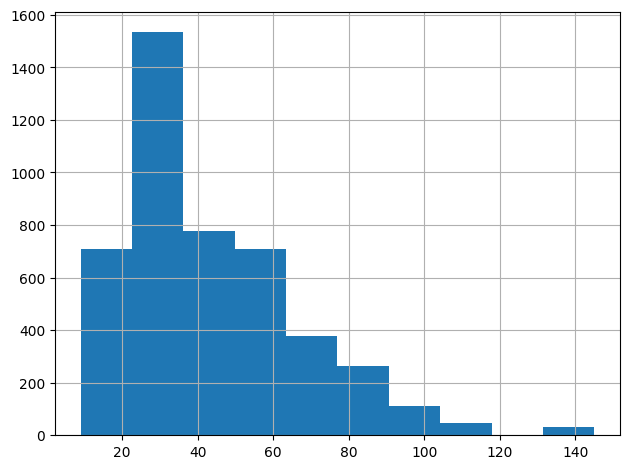

In [5]:
df["totalDeltaVKph"].hist()
plt.tight_layout()
plt.show()

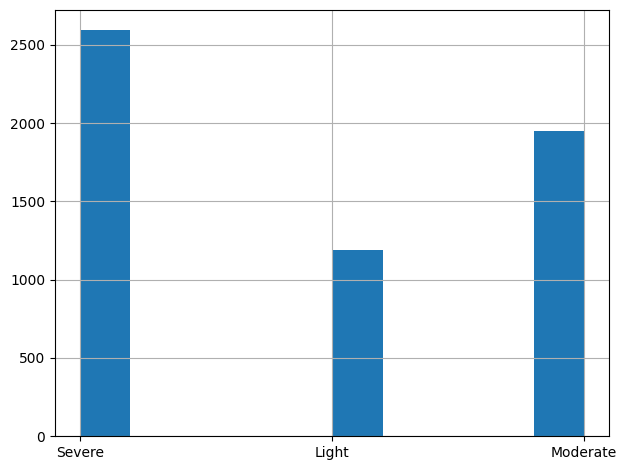

In [6]:
df["severityDescription"].hist()
plt.tight_layout()
plt.show()

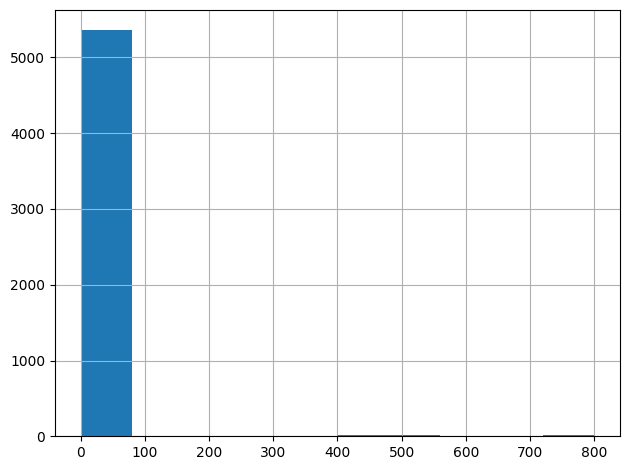

In [7]:
df["cargoWeightKg"].hist()
plt.tight_layout()
plt.show()

# Path Columns Inspection

In [8]:
df["image_filename"][0]

'52-kmph-32-mph_4-Severe_001_Vehicle1.jpg'

In [9]:
df["image_relpath"][0]

'utils/Preprocessing/NHTSADatabaseExtraction/Extraction/Images/CIREN/11/52-kmph-32-mph_4-Severe_001_Vehicle1.jpg'

# Velocity Columns Inspection

In [10]:
# Relevant columns
cols = [
    "totalDeltaVKph",
    "totalDeltaVMph",
    "noisy_dvBarrierEquivalentSpeedDescription"
]

# Check null values
print("-- NULL FIELDS")
print(df[cols].isna().sum())

# Records where totalDeltaVKph is missing

missing_kph = df[df["totalDeltaVKph"].isna()]

print("\n-- Records without totalDeltaVKph:", len(missing_kph))

# Check whether those records contain
# noisy_dvBarrierEquivalentSpeedDescription values
print(
    "\nValues of noisy_dvBarrierEquivalentSpeedDescription "
    "when totalDeltaVKph is missing:\n"
)

print(
    missing_kph["noisy_dvBarrierEquivalentSpeedDescription"]
    .value_counts(dropna=False)
)

print(
    missing_kph["noisy_dvBarrierEquivalentSpeedDescription"]
    .value_counts(dropna=False)
    .sum()
)

# Records where totalDeltaVMph is missing

missing_mph = df[df["totalDeltaVMph"].isna()]

print("\nRecords without totalDeltaVMph:", len(missing_mph))

print(
    "\nValues of noisy_dvBarrierEquivalentSpeedDescription "
    "when totalDeltaVMph is missing:\n"
)

print(
    missing_mph["noisy_dvBarrierEquivalentSpeedDescription"]
    .value_counts(dropna=False)
)

# Check null/non-null combinations

analysis = pd.DataFrame({
    "has_Kph": df["totalDeltaVKph"].notna(),
    "has_Mph": df["totalDeltaVMph"].notna(),
    "has_DV_desc": df["noisy_dvBarrierEquivalentSpeedDescription"].notna()
})

print("\nCombinations:")
print(analysis.value_counts())

# Problematic rows:
#    Missing totalDeltaVKph
#    AND missing noisy_dvBarrierEquivalentSpeedDescription

problematic = df[
    df["totalDeltaVKph"].isna() &
    df["noisy_dvBarrierEquivalentSpeedDescription"].isna()
]

print(
    "\nRows without totalDeltaVKph "
    "and without noisy_dvBarrierEquivalentSpeedDescription:",
    len(problematic)
)


-- NULL FIELDS
totalDeltaVKph                               1173
totalDeltaVMph                               1173
noisy_dvBarrierEquivalentSpeedDescription     561
dtype: int64

-- Records without totalDeltaVKph: 1173

Values of noisy_dvBarrierEquivalentSpeedDescription when totalDeltaVKph is missing:

noisy_dvBarrierEquivalentSpeedDescription
NaN           561
33.009228      30
34.480228      28
115.122791     26
34.791234      25
26.407157      25
58.849608      25
61.971161      24
60.844670      24
32.716419      23
45.370637      22
45.091991      22
67.839382      21
56.554486      20
35.938548      20
11.488755      20
64.820538      19
34.099874      18
33.033569      16
35.740246      16
78.591994      15
35.485620      15
47.536521      15
24.704266      14
35.250277      13
63.875944      12
12.858307      11
17.601791      11
55.998658      10
86.673991      10
61.667076      10
55.350583       9
17.658698       9
53.653888       9
23.857568       7
27.798588       7
11.92

In [11]:
problematic.head()

,image_id,cirenId,caseId,image_relpath,image_filename,vehicleNumber,image_sequence,photoId,objectID,description,...,primaryVehicleNumber,damagePlaneDescription,severityDescription,vehicleClass,curbWeight,curbWeightKg,cargoWeight,cargoWeightKg,dvBarrierEquivalentSpeedDescription,noisy_dvBarrierEquivalentSpeedDescription
126,ciren_19_Unknown_5-Critical_001_Vehicle1,19,8593,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,Unknown_5-Critical_001_Vehicle1.jpg,1,1,416414,CIREN/2017/4e788472-ca07-4c38-a49c-2b3f86ae0ff4,Down passenger’s side,...,1,Right side,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,Unknown,NaN
127,ciren_19_Unknown_5-Critical_002_Vehicle1,19,8593,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,Unknown_5-Critical_002_Vehicle1.jpg,1,2,416412,CIREN/2017/6317bf24-b108-4706-9c7f-ae855029daa3,Front,...,1,Right side,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,Unknown,NaN
128,ciren_19_Unknown_5-Critical_003_Vehicle1,19,8593,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,Unknown_5-Critical_003_Vehicle1.jpg,1,3,416417,CIREN/2017/49bc522c-2d6a-4601-9546-0146db6dc931,Down driver’s side,...,1,Right side,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,Unknown,NaN
129,ciren_19_Unknown_5-Critical_004_Vehicle1,19,8593,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,Unknown_5-Critical_004_Vehicle1.jpg,1,4,416443,CIREN/2017/7110256c-4a45-4859-a2ad-ca74e51e7d31,directional scraping on hood,...,1,Right side,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,Unknown,NaN
130,ciren_19_Unknown_5-Critical_005_Vehicle1,19,8593,utils/Preprocessing/NHTSADatabaseExtraction/Ex...,Unknown_5-Critical_005_Vehicle1.jpg,1,5,416413,CIREN/2017/790e7de9-5f92-4999-be90-1af64e84a47a,Front/right oblique,...,1,Right side,Severe,Intermediate (wheelbase >=265 but < 278 cm),1340 kgs,1340,0 kgs,0,Unknown,NaN


# Cut Samples with No Target Variable

In [12]:
# Remove rows where all 3 variables are missing

df = df[
    ~(
        df["totalDeltaVKph"].isna() &
        df["totalDeltaVMph"].isna() &
        df["noisy_dvBarrierEquivalentSpeedDescription"].isna()
    )
]

print("\nUpdated dataframe shape:", df.shape)

#  verify remaining null values
print("\nRemaining null values:")
print(df[[
    "totalDeltaVKph",
    "totalDeltaVMph",
    "noisy_dvBarrierEquivalentSpeedDescription"
]].isna().sum())


Updated dataframe shape: (5171, 28)

Remaining null values:
totalDeltaVKph                               612
totalDeltaVMph                               612
noisy_dvBarrierEquivalentSpeedDescription      0
dtype: int64


In [13]:
augmented_rows = []

# Iterate through original dataframe rows
for _, row in df.iterrows():

    original_rel_path = row["image_relpath"]

    # Create 3 augmented versions
    for aug_idx in range(3):

        # Copy original row
        new_row = row.copy()

        # Build augmented filename
        filename = f"aug_{aug_idx}_" + os.path.split(original_rel_path)[-1]

        # Build new relative path
        new_rel_path = os.path.join(
            os.path.dirname(original_rel_path),
            filename
        )

        # Replace relpath with augmented relpath
        new_row["image_relpath"] = new_rel_path

        augmented_rows.append(new_row)

# Create augmented dataframe
augmented_df = pd.DataFrame(augmented_rows)

print("Original dataframe size:", len(df))
print("Augmented dataframe size:", len(augmented_df))

augmented_df.head()

augmented_df.to_csv('../CSV/ciren_training_augmented_manifest.csv', index=False)

Original dataframe size: 5171
Augmented dataframe size: 15513


# Image Inspection

## Aux Dataframe Creation for Image Feature Analysis

In [14]:
BASE_PATH = "../../../"  


features = []

for rel_path in tqdm(augmented_df["image_relpath"]):

    full_path = os.path.join(BASE_PATH, rel_path)

    try:
        with Image.open(full_path) as img:

            # Basic info
            width, height = img.size
            mode = img.mode

            # Num channels
            channels = len(img.getbands())

            # Aspect ratio
            aspect_ratio = width / height

            # Orientation
            if width > height:
                orientation = "landscape"
            elif height > width:
                orientation = "portrait"
            else:
                orientation = "square"

            # File size
            file_size_kb = os.path.getsize(full_path) / 1024

            # Convert to numpy
            img_np = np.array(img)

            # Brightness
            brightness = img_np.mean()

            # Contrast
            contrast = img_np.std()

            features.append({
                "image_relpath": new_rel_path,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "channels": channels,
                "mode": mode,
                "orientation": orientation,
                "file_size_kb": file_size_kb,
                "brightness": brightness,
                "contrast": contrast
            })

    except Exception as e:
        print(f"Error with {new_rel_path}: {e}")

# Create DF
image_stats_df = pd.DataFrame(features)

print(len(image_stats_df))

# Save as csv
image_stats_df.to_csv('../CSV/ciren_training_augmented_image_stats.csv', index=False)


100%|██████████| 15513/15513 [00:07<00:00, 1946.53it/s]

15513


## Image Analysis

In [15]:
print(image_stats_df[["width", "height"]].describe())

         width   height
count  15513.0  15513.0
mean     224.0    224.0
std        0.0      0.0
min      224.0    224.0
25%      224.0    224.0
50%      224.0    224.0
75%      224.0    224.0
max      224.0    224.0


In [16]:
gray_images = image_stats_df[
    image_stats_df["channels"] == 1
]

print("Gray-Images: ",len(gray_images))

Gray-Images:  0


In [17]:
image_stats_df["orientation"].value_counts()

orientation
square    15513
Name: count, dtype: int64

WIDTH
Mean: 224.0
Median: 224.0


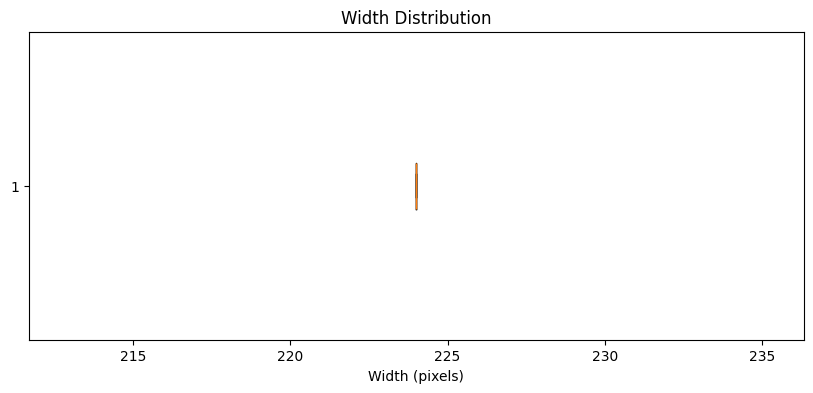


HEIGHT
Mean: 224.0
Median: 224.0


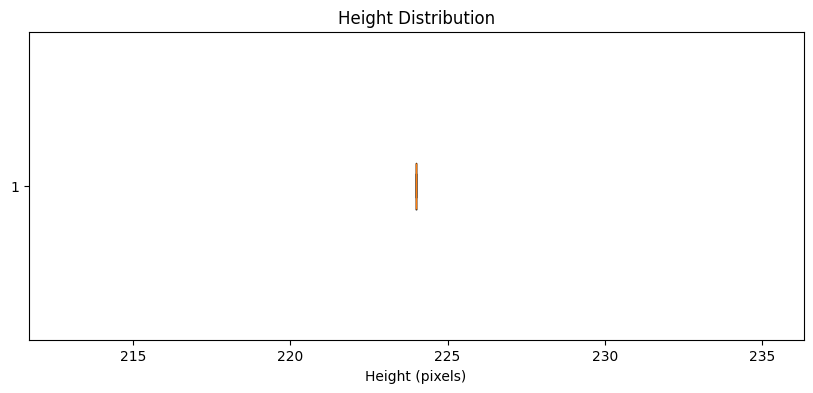

In [18]:
print("WIDTH")
print("Mean:", image_stats_df["width"].mean())
print("Median:", image_stats_df["width"].median())

# WIDTH BOXPLOT
plt.figure(figsize=(10, 4))
plt.boxplot(
    image_stats_df["width"],
    vert=False
)
plt.title("Width Distribution")
plt.xlabel("Width (pixels)")
plt.show()


print("\nHEIGHT")
print("Mean:", image_stats_df["height"].mean())
print("Median:", image_stats_df["height"].median())

# HEIGHT BOXPLOT
plt.figure(figsize=(10, 4))
plt.boxplot(
    image_stats_df["height"],
    vert=False
)
plt.title("Height Distribution")
plt.xlabel("Height (pixels)")
plt.show()

In [19]:
means = []
stds = []

for rel_path in tqdm(image_stats_df["image_relpath"]):

    full_path = os.path.join(BASE_PATH, rel_path)

    try:
        img = Image.open(full_path).convert("RGB")
        img = np.array(img) / 255.0

        means.append(img.mean(axis=(0,1)))
        stds.append(img.std(axis=(0,1)))

    except:
        pass

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("Mean:", mean)
print("Std:", std)

100%|██████████| 15513/15513 [00:31<00:00, 493.48it/s]

Mean: [0.45484897 0.47033188 0.47973604]
Std: [0.24885239 0.24789241 0.24780511]


# Add the definitive target column 

In [20]:
# Create final speed column
# Priority:
# 1. totalDeltaVKph
# 2. noisy_dvBarrierEquivalentSpeedDescription

augmented_df["final_speed_kph"] = (
    augmented_df["totalDeltaVKph"]
    .fillna(augmented_df["noisy_dvBarrierEquivalentSpeedDescription"])
)

# Verify results
print(
    augmented_df[[
        "totalDeltaVKph",
        "noisy_dvBarrierEquivalentSpeedDescription",
        "final_speed_kph"
    ]].head(5)
)

# Check remaining nulls
print("\nRemaining null values in final_speed_kph:")
print(augmented_df["final_speed_kph"].isna().sum())

  totalDeltaVKph  noisy_dvBarrierEquivalentSpeedDescription final_speed_kph
0             52                                  46.315825              52
0             52                                  46.315825              52
0             52                                  46.315825              52
1             52                                  46.315825              52
1             52                                  46.315825              52

Remaining null values in final_speed_kph:
0


# Save Dataset Manifest as CSV for Torch DataLoader

In [21]:
augmented_df.to_csv('../CSV/ciren_training_augmented_manifest.csv', index=False)